## 📊 Statistical Analysis & Visualization
**Paper:** *The Schizophrenia of Global Food Safety: A Comparative Longitudinal Analysis (2008-2025)*   
**Author:** Md Shafin Ahamed  

### 📝 Overview
This notebook performs the statistical analysis and generates the final figures and tables for the manuscript. It utilizes the clean, harmonized datasets generated by the `Data_Harmonization` pipeline.

### 📉 Key Deliverables
This notebook generates the following artifacts cited in the paper:

* **Table 2 (Sector Inversion):** Calculates the procedural divergence in high-volume sectors (Agriculture vs. Seafood vs. Nuts).
* **Figure 3 (Geopolitical Risk Map):** Visualizes the "Neighborhood Bias" (Mexico/Turkey) and the "India Paradox" (Dual Compliance friction).
* **Figure 4 (Hazard DNA):** Plots the aggregate distribution of the 7 Hazard Classes, identifying the "Toxicological Sentinel" (EU) vs. "Hygiene Police" (US) dynamic.
* **The "China Control" Analysis:** Statistical validation of China's dual-risk profile (Chemicals in US vs. Toxins in EU).

### 🛠️ Dependencies
* **Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`.
* **Input Data:** Requires the `_harmonized.csv` files generated in the previous step.

> **Note:** Ensure file paths in the `read_csv` command match your local directory structure before running.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_fda = pd.read_csv (r"D:\data_files\Journal\data\FDA_Import_Refusals_Human_Foods_harmonized.csv", low_memory = False, encoding = 'utf-8')
df_rasff = pd.read_csv(r"D:\data_files\Journal\data\RASFF_Alert_Notifications_(1979-2025)_harmonized.csv", low_memory = False)
print ('Done!')

Done!


In [3]:
df_fda.columns

Index(['FEI Number', 'Firm Legal Name', 'Firm Address',
       'Product Code and Description', 'Refused Date', 'Import Division',
       'Shipment ID', 'FDA Sample Analysis', 'Private Lab Analysis',
       'Refusal Charges', 'Date', 'Product_code', 'Year', 'Product_category',
       'Country', 'Reason', 'Sector', 'Hazard_Group'],
      dtype='object')

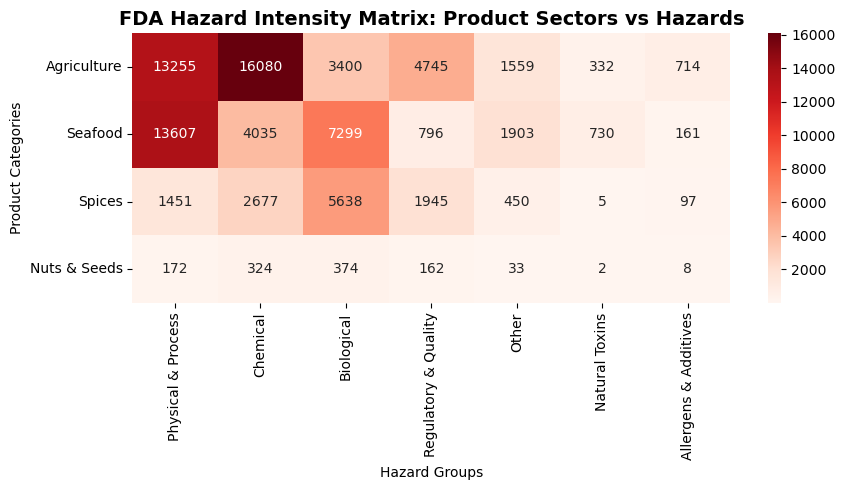

In [12]:
#====================================       FIGURE 1       ====================================

#FDA Hazard Intensity Matrix
fda_all_hazards = df_fda['Hazard_Group'].value_counts().index
fda_all_sectors = df_fda['Sector'].value_counts().index

subset = df_fda[df_fda['Hazard_Group'].isin(fda_all_hazards) & 
            df_fda['Sector'].isin(fda_all_sectors)]

pivot_table = pd.crosstab(subset['Sector'], subset['Hazard_Group'])

# This forces the rows and columns to follow the order of importance, not the alphabet.
pivot_table = pivot_table.reindex(index=fda_all_sectors, columns=fda_all_hazards)

# Plot heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='Reds',)
plt.title('FDA Hazard Intensity Matrix: Product Sectors vs Hazards', fontsize=14, fontweight='bold')
plt.ylabel('Product Categories', fontsize=10)
plt.xlabel('Hazard Groups', fontsize=10)
plt.yticks(rotation = 0)
#plt.savefig( "Figure1_new.png", bbox_inches='tight', dpi = 300) #"Image1_FDA_Food_Products_vs_Hazard_Groups.png"
plt.tight_layout()
plt.show()

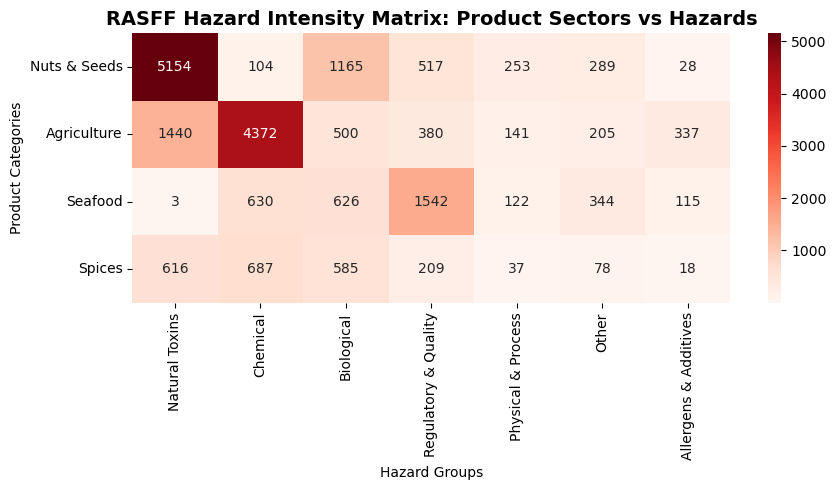

In [13]:
#====================================       FIGURE 2       ====================================

#RASFF Hazard Intensity Matrix
rasff_all_hazards = df_rasff['Hazard_Group'].value_counts().index
rasff_all_sectors = df_rasff['Sector'].value_counts().index

subset = df_rasff[df_rasff['Hazard_Group'].isin(rasff_all_hazards) & 
            df_rasff['Sector'].isin(rasff_all_sectors)]

pivot_table = pd.crosstab(subset['Sector'], subset['Hazard_Group'])

pivot_table = pivot_table.reindex(index=rasff_all_sectors, columns=rasff_all_hazards)

# Plot heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='Reds',)
plt.title('RASFF Hazard Intensity Matrix: Product Sectors vs Hazards', fontsize=14, fontweight='bold')
plt.ylabel('Product Categories', fontsize=10)
plt.xlabel('Hazard Groups', fontsize=10)
plt.yticks(rotation = 0)
#plt.savefig( "Figure2_new.png", bbox_inches='tight', dpi = 300)#"Image2_RASFF_Food_Products_vs_Hazard_Groups.png"
plt.tight_layout()
plt.show()

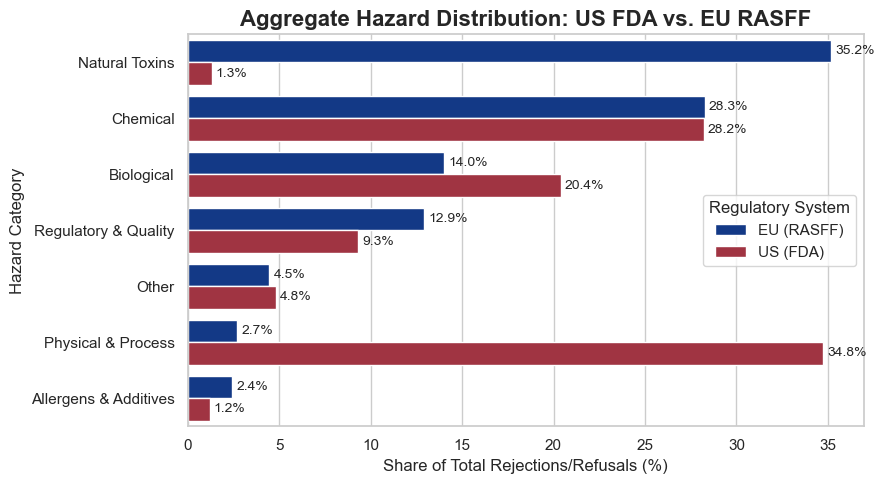

In [18]:
#====================================       FIGURE 3       ====================================

#PREPARE THE DATA 

# Calculate Counts
rasff_counts = df_rasff['Hazard_Group'].value_counts().reset_index()
rasff_counts.columns = ['Hazard_Group', 'Count']
rasff_counts['Source'] = 'EU (RASFF)'
rasff_counts['Percentage'] = (rasff_counts['Count'] / rasff_counts['Count'].sum()) * 100

fda_counts = df_fda['Hazard_Group'].value_counts().reset_index()
fda_counts.columns = ['Hazard_Group', 'Count']
fda_counts['Source'] = 'US (FDA)'
fda_counts['Percentage'] = (fda_counts['Count'] / fda_counts['Count'].sum()) * 100

# Combine them into one table
comparison_df = pd.concat([rasff_counts, fda_counts])


plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

#Bar Chart comparing with PERCENTAGES
ax = sns.barplot(
    data=comparison_df,
    x='Percentage',
    y='Hazard_Group',
    hue='Source',
    palette={'EU (RASFF)': '#003399', 'US (FDA)': '#B22234'} # EU Blue & US Red
)

#Title and labels
plt.title('Aggregate Hazard Distribution: US FDA vs. EU RASFF', fontsize=16, fontweight='bold')
plt.xlabel('Share of Total Rejections/Refusals (%)', fontsize=12)
plt.ylabel('Hazard Category', fontsize=12)
plt.legend(title='Regulatory System')

# Add Labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
#plt.savefig("Image3_Regulatory_Divergence.png", dpi=300)
plt.savefig( "Figure4_Aggregate_Hazard_Distribution.png", bbox_inches='tight', dpi = 300)
plt.show()


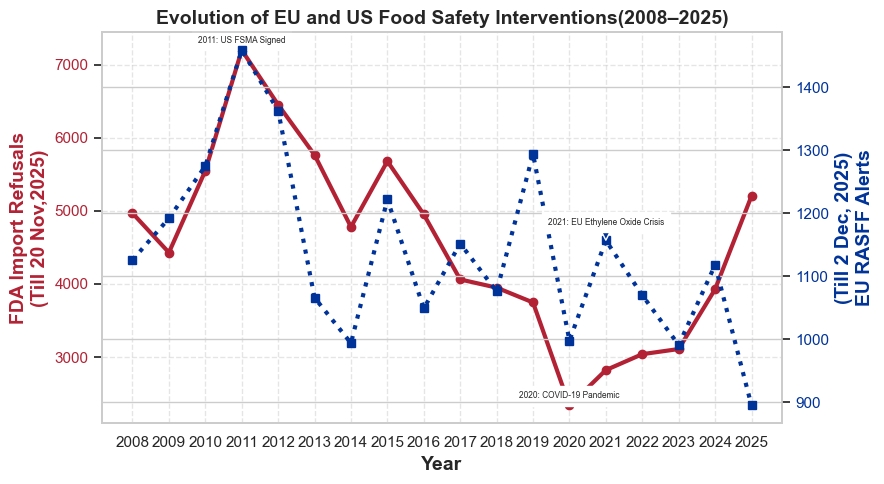

In [39]:
#====================================       FIGURE 4       ====================================

# Group RASFF by Year
rasff_trend = df_rasff['New_Year'].value_counts().sort_index()

# Group FDA by Year
fda_trend = df_fda['Year'].value_counts().sort_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot FDA on Left Axis
color_fda = '#B22234'  # US Red
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
ax1.set_ylabel('FDA Import Refusals\n(Till 20 Nov,2025)', color=color_fda, fontsize=14, fontweight='bold')

ax1.plot(
    fda_trend.index, fda_trend.values,
    color=color_fda, linewidth=3, marker='o',
    label='US FDA Refusals'
)

ax1.tick_params(axis='y', labelcolor=color_fda)
ax1.grid(True, linestyle='--', alpha=0.5)

# RASFF axis
ax2 = ax1.twinx()
color_rasff = '#003399'  # EU Blue

ax2.set_ylabel('(Till 2 Dec, 2025)\nEU RASFF Alerts', color=color_rasff, fontsize=14, fontweight='bold')
ax2.plot(
    rasff_trend.index, rasff_trend.values,
    color=color_rasff, linewidth=3, marker='s',
    linestyle=':', label='EU RASFF Alerts'
)

ax2.tick_params(axis='y', labelcolor=color_rasff)

# Event markers for FDA
events = {
    2011: "2011: US FSMA Signed",
    2020: "2020: COVID-19 Pandemic"
}

for year, event in events.items():
    if year in fda_trend.index:
        ax1.annotate(
            event,
            xy=(year, fda_trend[year]),
            xytext=(year, fda_trend[year] + 100),
            arrowprops=dict(facecolor='#B22234', shrink=0.01),
            fontsize=6, ha='center', backgroundcolor='white'
        )

# Event markers for RASFF
events_rasff = {
    2021: "2021: EU Ethylene Oxide Crisis"
}

for year2, event in events_rasff.items():
    if year2 in rasff_trend.index:
        ax2.annotate(
            event,
            xy=(year2, rasff_trend[year2]),
            xytext=(year2, rasff_trend[year2] + 25),
            arrowprops=dict(facecolor='#003399', shrink=0.01),
            fontsize=6, ha='center', backgroundcolor='white'
        )

# Title
plt.title('Evolution of EU and US Food Safety Interventions(2008–2025)',
          fontsize=14, fontweight='bold')

fig.tight_layout()
plt.xticks(range(2008,2026))
plt.savefig( "Figure1_Evolution_of_Food_Safety_Interventions.png", bbox_inches='tight', dpi = 300)
plt.show()


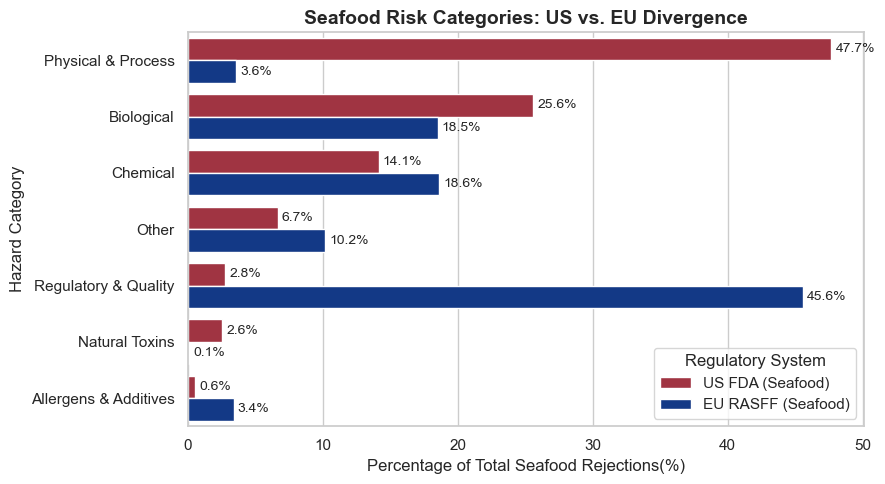

In [35]:
#====================================       FIGURE 5       ====================================

#FILTER FOR SEAFOOD ONLY 

# FDA: Filter for "Fishery/Seafood"
fda_vegetable = df_fda[df_fda['Sector'] == 'Seafood'].copy()

# RASFF: Filter for "Seafood" (Using the Sector map)
rasff_vegetable = df_rasff[df_rasff['Sector'] == 'Seafood'].copy()

# 2. CALCULATE RISK PROFILES 

# Calculate Percentages for FDA Seafood
fda_risks = fda_vegetable['Hazard_Group'].value_counts(normalize=True).reset_index()
fda_risks.columns = ['Hazard_Group', 'Percentage']
fda_risks['Source'] = 'US FDA (Seafood)'

# Calculate Percentages for RASFF Seafood
rasff_risks = rasff_vegetable['Hazard_Group'].value_counts(normalize=True).reset_index()
rasff_risks.columns = ['Hazard_Group', 'Percentage']
rasff_risks['Source'] = 'EU RASFF (Seafood)'

# Combine
Vegetable_comparison = pd.concat([fda_risks, rasff_risks])
Vegetable_comparison['Percentage'] = Vegetable_comparison['Percentage'] * 100

# 3. PLOT THE COMPARISON 
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=Vegetable_comparison,
    y='Hazard_Group',
    x='Percentage',
    hue='Source',
    palette={'EU RASFF (Seafood)': '#003399', 'US FDA (Seafood)': '#B22234'},
    orient='h'
)

# Add Labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, weight = 300)


# Styling
plt.title('Seafood Risk Categories: US vs. EU Divergence', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Seafood Rejections(%)', fontsize=12)
plt.ylabel('Hazard Category', fontsize=12)
plt.legend(title='Regulatory System')

plt.tight_layout()
plt.savefig( "SubFigure1_Seafood.png", bbox_inches='tight', dpi = 300)
plt.show()

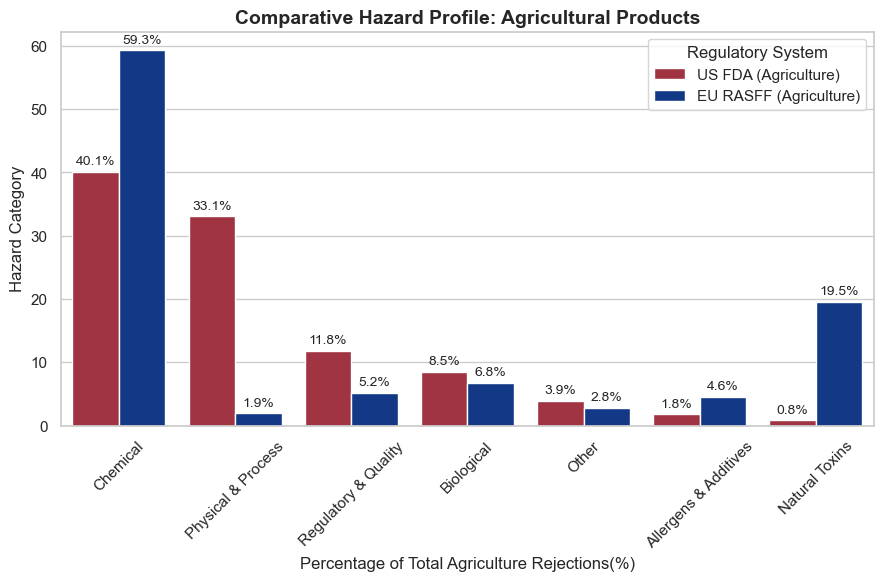

In [36]:
#====================================       FIGURE 6       ====================================

#FILTER FOR Agriculture

fda_veg = df_fda[df_fda['Sector'] == 'Agriculture'].copy()

# RASFF
rasff_veg = df_rasff[df_rasff['Sector'] == 'Agriculture'].copy()

# 2. CALCULATE RISK PROFILES 

# FDA Risks
fda_risks = fda_veg['Hazard_Group'].value_counts(normalize=True).reset_index()
fda_risks.columns = ['Hazard_Group', 'Percentage']
fda_risks['Percentage'] = fda_risks['Percentage'] * 100
fda_risks['System'] = 'US FDA (Agriculture)'

# RASFF Risks
rasff_risks = rasff_veg['Hazard_Group'].value_counts(normalize=True).reset_index()
rasff_risks.columns = ['Hazard_Group', 'Percentage']
rasff_risks['Percentage'] = rasff_risks['Percentage'] * 100
rasff_risks['System'] = 'EU RASFF (Agriculture)'

# Combine
veg_comparison = pd.concat([fda_risks, rasff_risks])

#PLOT
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=veg_comparison,
    x='Hazard_Group',
    y='Percentage',
    hue='System',
    palette={'EU RASFF (Agriculture)': '#003399', 'US FDA (Agriculture)': '#B22234'}, # Darker Red for Vegetable
    orient='v'
)

# Styling
plt.title("Comparative Hazard Profile: Agricultural Products", fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Agriculture Rejections(%)', fontsize=12)
plt.ylabel('Hazard Category', fontsize=12)
plt.legend(title='Regulatory System')

# Add Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig( "SubFigure2_Agriculture.png", bbox_inches='tight', dpi = 300)
plt.show()

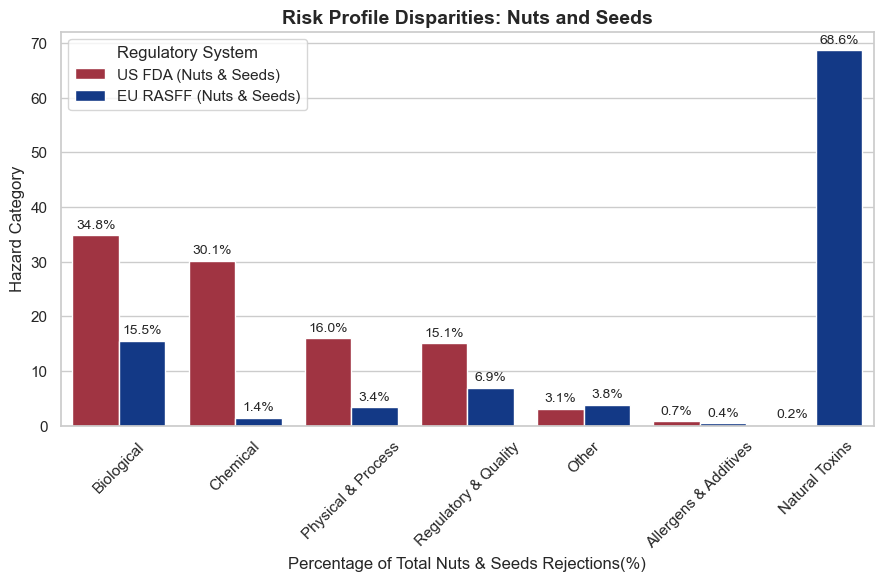

In [37]:
#====================================       FIGURE 7       ====================================

# 2. FILTER Nuts & Seeds
fda_veg = df_fda[df_fda['Sector'] == 'Nuts & Seeds'].copy()

# RASFF: Filter for  Nuts & Seeds
rasff_veg = df_rasff[df_rasff['Sector'] == 'Nuts & Seeds'].copy()

# 2. CALCULATE RISK PROFILES 

# FDA Risks
fda_risks = fda_veg['Hazard_Group'].value_counts(normalize=True).reset_index()
fda_risks.columns = ['Hazard_Group', 'Percentage']
fda_risks['Percentage'] = fda_risks['Percentage'] * 100
fda_risks['System'] = 'US FDA (Nuts & Seeds)'

# RASFF Risks
rasff_risks = rasff_veg['Hazard_Group'].value_counts(normalize=True).reset_index()
rasff_risks.columns = ['Hazard_Group', 'Percentage']
rasff_risks['Percentage'] = rasff_risks['Percentage'] * 100
rasff_risks['System'] = 'EU RASFF (Nuts & Seeds)'

#Combine
veg_comparison = pd.concat([fda_risks, rasff_risks])

#PLOT
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=veg_comparison,
    x='Hazard_Group',
    y='Percentage',
    hue='System',
    palette={'EU RASFF (Nuts & Seeds)': '#003399', 'US FDA (Nuts & Seeds)': '#B22234'}, # Darker Red for Vegetable
    orient='v'
)

# Styling
plt.title("Risk Profile Disparities: Nuts and Seeds", fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Nuts & Seeds Rejections(%)', fontsize=12)
plt.ylabel('Hazard Category', fontsize=12)
plt.legend(title='Regulatory System')

# Add Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig( "SubFigure3_Nuts_and_seeds.png", bbox_inches='tight', dpi = 300)
plt.show()

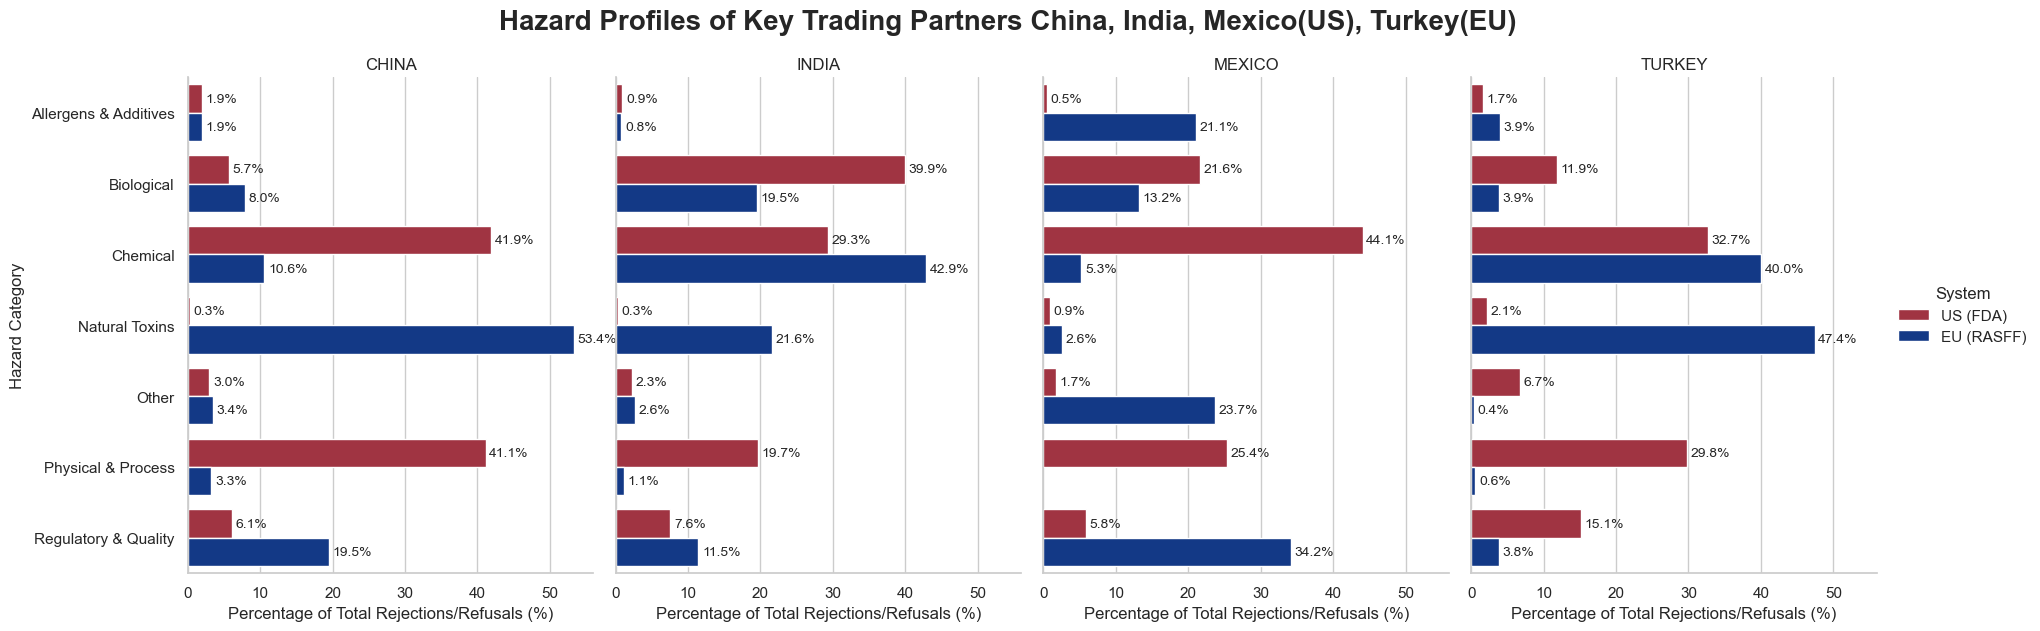

In [54]:
#====================================       FIGURE 8       ====================================

df_fda = df_fda.reset_index(drop=True)

df_rasff = df_rasff.reset_index(drop=True) 

target_countries = ['CHINA', 'INDIA', 'TURKEY', 'MEXICO']

#PREPARE FDA DATA
# Standardize to Upper Case
df_fda['Country_Upper'] = df_fda['Country'].astype(str).str.upper()

#Filter for the 4 targets
fda_subset = df_fda[df_fda['Country_Upper'].isin(target_countries)].copy()

#Group by Country and Hazard
fda_country_risks = fda_subset.groupby(['Country_Upper', 'Hazard_Group']).size().reset_index(name='Count')

#Calculate percentage
fda_country_risks['Percentage'] = fda_country_risks.groupby('Country_Upper')['Count'].transform(lambda x: x / x.sum() * 100)
fda_country_risks['System'] = 'US (FDA)'

# Rename 'Country_Upper' to just 'Country' for the merge
fda_country_risks = fda_country_risks.rename(columns={'Country_Upper': 'Country'})


#Standardize to Upper Case
df_rasff['Origin_Upper'] = df_rasff['Origin_Clean'].astype(str).str.upper()

#Filter for the 3 targets
rasff_subset = df_rasff[df_rasff['Origin_Upper'].isin(target_countries)].copy()

#Group by Country and Hazard
rasff_country_risks = rasff_subset.groupby(['Origin_Upper', 'Hazard_Group']).size().reset_index(name='Count')

# Calculate percentage
rasff_country_risks['Percentage'] = rasff_country_risks.groupby('Origin_Upper')['Count'].transform(lambda x: x / x.sum() * 100)
rasff_country_risks['System'] = 'EU (RASFF)'

# Rename 'Origin_Upper' to 'Country'
rasff_country_risks = rasff_country_risks.rename(columns={'Origin_Upper': 'Country'})


final_comparison = pd.concat([fda_country_risks, rasff_country_risks])

#Create the FacetGrid
g = sns.catplot(
    data=final_comparison, 
    x='Percentage', 
    y='Hazard_Group', 
    hue='System', 
    col='Country', 
    kind='bar',
    height=6, 
    aspect=0.8,
    palette={'EU (RASFF)': '#003399', 'US (FDA)': '#B22234'},
    sharex=True,
    legend_out=True
)

# Styling
g.fig.suptitle("Hazard Profiles of Key Trading Partners China, India, Mexico(US), Turkey(EU)", y=1.05, fontsize=20, weight='bold')
g.set_axis_labels("Percentage of Total Rejections/Refusals (%)", "Hazard Category")
g.set_titles("{col_name}")

# Add labels at end of each bar
for ax in g.axes.flatten():               # Loop over each subplot
    for p in ax.patches:                  # Loop over each bar
        value = p.get_width()             # Bar length (since x='Percentage')
        if value > 0:
            ax.text(
                p.get_x() + value + 0.5,  # Position label a little to right of bar
                p.get_y() + p.get_height()/2,
                f"{value:.1f}%",          # Format 1 decimal place
                va='center', ha='left', fontsize=10
            )

# Save
plt.savefig( "Figure3_Key_Trading_Partners.png", bbox_inches='tight', dpi = 300)
plt.show()

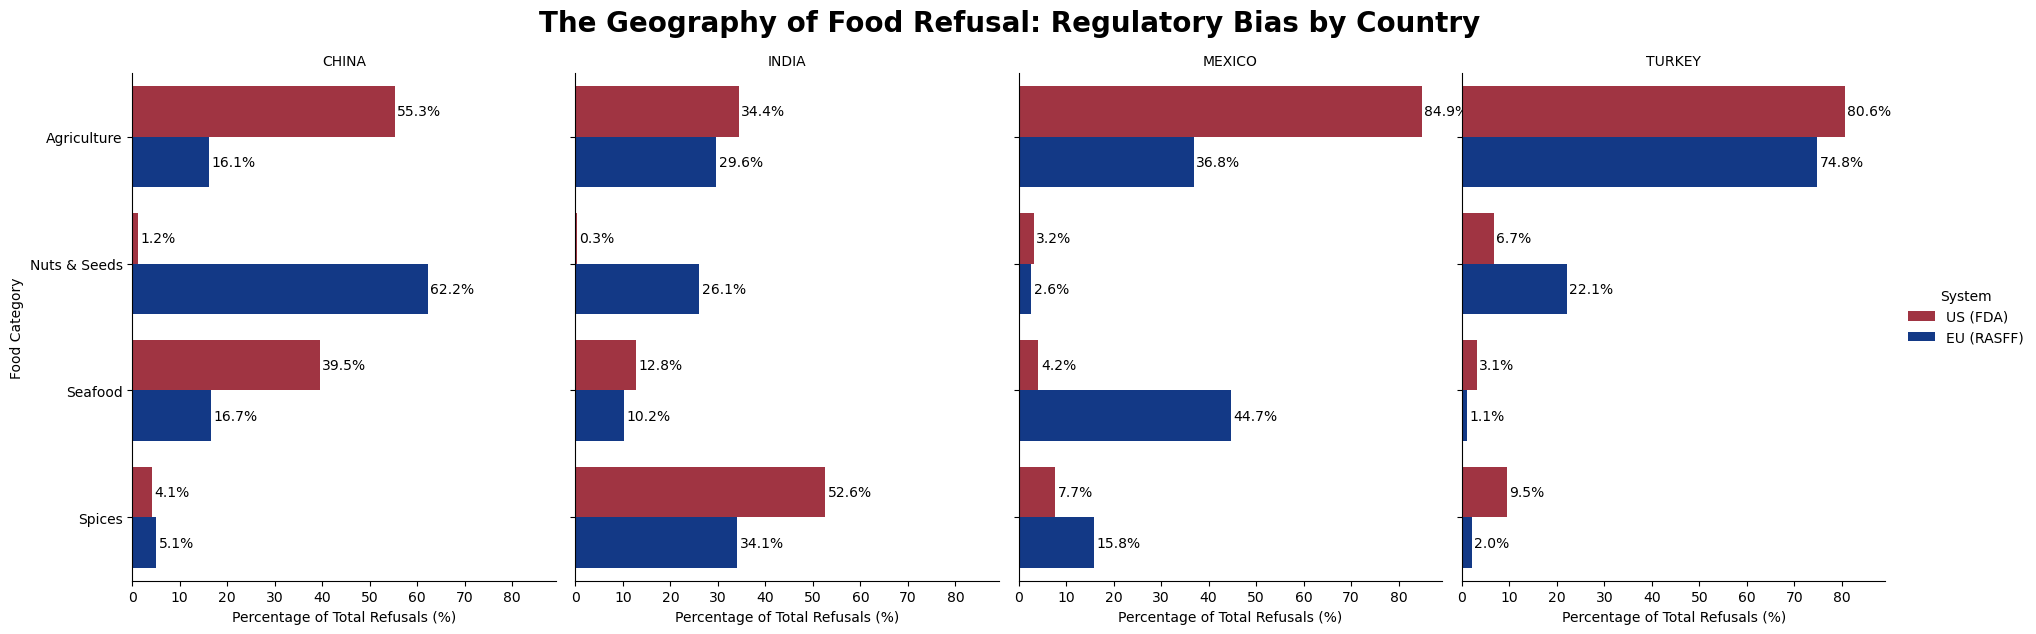

In [4]:
#====================================       FIGURE 9       ====================================

df_fda = df_fda.reset_index(drop=True)
df_rasff = df_rasff.reset_index(drop=True) 


target_countries = ['CHINA', 'INDIA', 'TURKEY', 'MEXICO']

#Standardize to Upper Case
df_fda['Country_Upper'] = df_fda['Country'].astype(str).str.upper()

#Filter for the 4 targets
fda_subset = df_fda[df_fda['Country_Upper'].isin(target_countries)].copy()

#Group by Country and Sector
fda_country_risks = fda_subset.groupby(['Country_Upper', 'Sector']).size().reset_index(name='Count')

# Calculate percentage (Count / Total for that Country * 100)
fda_country_risks['Percentage'] = fda_country_risks.groupby('Country_Upper')['Count'].transform(lambda x: x / x.sum() * 100)
fda_country_risks['System'] = 'US (FDA)'

#Rename 'Country_Upper' to just 'Country' for the merge
fda_country_risks = fda_country_risks.rename(columns={'Country_Upper': 'Country'})

#Standardize to Upper Case
df_rasff['Origin_Upper'] = df_rasff['Origin_Clean'].astype(str).str.upper()

# Filter for the 3 targets
rasff_subset = df_rasff[df_rasff['Origin_Upper'].isin(target_countries)].copy()

#Group by Country and Hazard
rasff_country_risks = rasff_subset.groupby(['Origin_Upper', 'Sector']).size().reset_index(name='Count')

# Calculate percentage
rasff_country_risks['Percentage'] = rasff_country_risks.groupby('Origin_Upper')['Count'].transform(lambda x: x / x.sum() * 100)
rasff_country_risks['System'] = 'EU (RASFF)'

#Rename 'Origin_Upper' to 'Country'
rasff_country_risks = rasff_country_risks.rename(columns={'Origin_Upper': 'Country'})


final_comparison = pd.concat([fda_country_risks, rasff_country_risks])

#Create the FacetGrid
g = sns.catplot(
    data=final_comparison, 
    x='Percentage', 
    y='Sector', 
    hue='System', 
    col='Country', 
    kind='bar',
    height=6, 
    aspect=0.8,
    palette={'EU (RASFF)': '#003399', 'US (FDA)': '#B22234'},
    sharex=True,
    legend_out=True
)

#Styling
g.fig.suptitle("The Geography of Food Refusal: Regulatory Bias by Country", y=1.05, fontsize=20, weight='bold')
g.set_axis_labels("Percentage of Total Refusals (%)", "Food Category")
g.set_titles("{col_name}")

# Add labels at end of each bar
for ax in g.axes.flatten():               # Loop over each subplot
    for p in ax.patches:                  # Loop over each bar
        value = p.get_width()             # Bar length (since x='Percentage')
        if value > 0:
            ax.text(
                p.get_x() + value + 0.5,  # Position label a little to right of bar
                p.get_y() + p.get_height()/2,
                f"{value:.1f}%",          # Format 1 decimal place
                va='center', ha='left', fontsize=10
            )


# Save
plt.savefig("Figure9_The_Geography_of_Food_Refusal.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [29]:
#====================================       Table       ====================================


def generate_country_table(df, country_col, hazard_col, system_name):
    # 1. Get Top 5 Countries by Total Count
    top_countries = df[country_col].value_counts().nlargest(5).index.tolist()
    
    results = []
    for rank, country in enumerate(top_countries, 1):
        # Filter for this specific country
        country_data = df[df[country_col] == country]
        total_count = len(country_data)
        
        # Find the #1 Risk (Hazard_Group) for this country
        if not country_data.empty:
            top_risk = country_data[hazard_col].value_counts().idxmax()
            risk_count = country_data[hazard_col].value_counts().max()
            risk_pct = (risk_count / total_count) * 100
            risk_str = f"{top_risk} ({risk_pct:.1f}%)"
        else:
            risk_str = "N/A"
            
        results.append({
            'Rank': rank,
            'System': system_name,
            'Country': country,
            'Total Rejections': total_count,
            'Primary Driver': risk_str
        })
    
    return pd.DataFrame(results)

#GENERATE TABLE 1 (Geopolitics)
# Generating FDA part
t1_fda = generate_country_table(df_fda, 'Country', 'Hazard_Group', 'US-FDA')

# Generating RASFF part 
t1_rasff = generate_country_table(df_rasff, 'Origin_Clean', 'Hazard_Group', 'EU-RASFF')

print("=== TABLE 1: Top Trading Partners & Their Risks ===")
# Displaying them separately to avoid confusion
# Generating the results into LaTeX format.
print("--- US FDA Top 5 ---")
print(t1_fda.to_latex(index=False))
print("\n--- EU RASFF Top 5 ---")
print(t1_rasff.to_latex(index=False))


#GENERATE TABLE 2 (Sector Inversion)
def generate_sector_table(df, sector_col, system_name):
    # Count totals per sector
    counts = df[sector_col].value_counts()
    total = counts.sum()
    
    # Calculate percentages
    pcts = (counts / total * 100).round(1)
    
    # Combine into a dataframe
    stats = pd.DataFrame({'Count': counts, 'Share (%)': pcts})
    stats['System'] = system_name
    return stats

# Generate stats
s_fda = generate_sector_table(df_fda, 'Sector', 'US-FDA')
s_rasff = generate_sector_table(df_rasff, 'Sector', 'EU-RASFF')

# Combine and Format
table_2 = pd.concat([s_fda, s_rasff], axis=0).reset_index().rename(columns={'index':'Sector'})
table_2_pivot = table_2.pivot(index='Sector', columns='System', values=['Count', 'Share (%)'])

print("\n=== TABLE 2: The Sector Priority Inversion ===")
print(table_2_pivot.to_latex())

=== TABLE 1: Top Trading Partners & Their Risks ===
--- US FDA Top 5 ---
\begin{tabular}{rllrl}
\toprule
Rank & System & Country & Total Rejections & Primary Driver \\
\midrule
1 & US-FDA & India & 11501 & Biological (39.9%) \\
2 & US-FDA & Mexico & 10865 & Chemical (44.1%) \\
3 & US-FDA & China & 8269 & Chemical (41.9%) \\
4 & US-FDA & Vietnam & 4406 & Physical & Process (38.3%) \\
5 & US-FDA & Indonesia & 4333 & Physical & Process (45.7%) \\
\bottomrule
\end{tabular}


--- EU RASFF Top 5 ---
\begin{tabular}{rllrl}
\toprule
Rank & System & Country & Total Rejections & Primary Driver \\
\midrule
1 & EU-RASFF & Turkey & 4539 & Natural Toxins (47.4%) \\
2 & EU-RASFF & India & 2777 & Chemical (42.9%) \\
3 & EU-RASFF & China & 1597 & Natural Toxins (53.4%) \\
4 & EU-RASFF & United States of America & 1074 & Natural Toxins (78.9%) \\
5 & EU-RASFF & Egypt & 946 & Chemical (46.9%) \\
\bottomrule
\end{tabular}


=== TABLE 2: The Sector Priority Inversion ===
\begin{tabular}{lrrrr}
\toprule
 & 

In [12]:
df_fda.columns

Index(['FEI Number', 'Firm Legal Name', 'Firm Address',
       'Product Code and Description', 'Refused Date', 'Import Division',
       'Shipment ID', 'FDA Sample Analysis', 'Private Lab Analysis',
       'Refusal Charges', 'Date', 'Product_code', 'Year', 'Product_category',
       'Country', 'Reason', 'Sector', 'Hazard_Group'],
      dtype='object')

In [21]:
#Extacting Lab analysis Data From FDA.


print (f" --- Analysis Breakdown of FDA Import Refusdals:\n {df_fda['FDA Sample Analysis'].value_counts()}")
fd_fda_no = df_fda[df_fda['FDA Sample Analysis'] == 'No']
print (f" --- Not Analyzed Sector Breakdown:\n {fd_fda_not['Sector'].value_counts()}")
fd_fda_yes = df_fda[df_fda['FDA Sample Analysis'] == 'Yes']
print (f" --- Analyzed Sector Breakdown:\n {fd_fda_yes['Sector'].value_counts()}")

 --- Analysis Breakdown of FDA Import Refusdals:
 FDA Sample Analysis
No     62561
Yes    19393
Name: count, dtype: int64
 --- Not Analyzed Sector Breakdown:
 Sector
Agriculture     30291
Seafood         21260
Spices          10155
Nuts & Seeds      855
Name: count, dtype: int64
 --- Analyzed Sector Breakdown:
 Sector
Agriculture     9794
Seafood         7271
Spices          2108
Nuts & Seeds     220
Name: count, dtype: int64
